# Ejercicio 4: Modelo Probabilístico

### Nombre: Anthony Goyes

### Paso 0: Cargar el corpus 

In [1]:
import os

ruta = "../data/gutenberg/gutenberg_1000"

corpus = []
nombres = []

for archivo in sorted(os.listdir(ruta)):
    if archivo.endswith(".txt"):
        with open(os.path.join(ruta, archivo), "r", encoding="utf-8", errors="ignore") as f:
            texto = f.read()
            corpus.append(texto)
            nombres.append(archivo)

print("Documentos:", len(corpus))

Documentos: 1000


### Parte 1: Cálculo de TF, DF, IDF y TF-IDF

In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000, stop_words="english")

tfidf = vectorizer.fit_transform(corpus)

print(tfidf.shape)

(1000, 5000)


### DF (Document Frequency)

In [3]:
import numpy as np

df = (tfidf > 0).sum(axis=0)
df = np.asarray(df).flatten()

### IDF

In [4]:
idf = vectorizer.idf_

### DataFrame

In [5]:
import pandas as pd

terminos = vectorizer.get_feature_names_out()

df_tabla = pd.DataFrame({
    "Termino": terminos,
    "DF": df,
    "IDF": idf
})

df_tabla.sort_values(by="IDF", ascending=False).head(10)

,Termino,DF,IDF
583,boffin,1,7.215608
3080,obs3,1,7.215608
306,ansifont,1,7.215608
1864,font40,1,7.215608
1696,fabrice,2,6.810142
3,00000,2,6.810142
4997,zoˆl,2,6.810142
2783,mansoul,2,6.810142
1852,fogg,4,6.299317
3044,noght,4,6.299317


### Parte 2: Ranking TF-IDF

### Consulta

In [7]:
from sklearn.metrics.pairwise import cosine_similarity

query = "love marriage family"

query_vec = vectorizer.transform([query])

scores_tfidf = cosine_similarity(query_vec, tfidf).flatten()

ranking_tfidf = scores_tfidf.argsort()[::-1][:10]

### Resultados

In [8]:
resultados_tfidf = pd.DataFrame({
    "Documento": [nombres[i] for i in ranking_tfidf],
    "Score_TFIDF": scores_tfidf[ranking_tfidf]
})

resultados_tfidf

,Documento,Score_TFIDF
0,book_0376.txt,0.213817
1,book_0572.txt,0.182798
2,book_0418.txt,0.173691
3,book_0445.txt,0.172837
4,book_0762.txt,0.167915
5,book_0417.txt,0.157834
6,book_0238.txt,0.137293
7,book_0549.txt,0.136130
8,book_0658.txt,0.133830
9,book_0362.txt,0.130506


### PARTE 3: Ranking con BM25

### Tokenización

In [9]:
from collections import Counter
import math

tokenized_corpus = [doc.lower().split() for doc in corpus]

### Longitudes

In [10]:
doc_lengths = [len(doc) for doc in tokenized_corpus]
avgdl = sum(doc_lengths) / len(doc_lengths)

### DF Manual

In [11]:
df_bm25 = {}

for doc in tokenized_corpus:
    for term in set(doc):
        df_bm25[term] = df_bm25.get(term, 0) + 1

### IDF BM25

In [12]:
N = len(tokenized_corpus)

idf_bm25 = {}

for term, freq in df_bm25.items():
    idf_bm25[term] = math.log((N - freq + 0.5) / (freq + 0.5) + 1)

### Parámetros

In [13]:
k1 = 1.5
b = 0.75

### Función BM25

In [14]:
def bm25_score(query, doc, doc_len):
    score = 0
    doc_freq = Counter(doc)

    for term in query:
        if term not in doc_freq:
            continue

        tf = doc_freq[term]
        idf = idf_bm25.get(term, 0)

        num = tf * (k1 + 1)
        den = tf + k1 * (1 - b + b * (doc_len / avgdl))

        score += idf * (num / den)

    return score

### Ranking BM25

In [15]:
query_terms = query.lower().split()

scores_bm25 = []

for i, doc in enumerate(tokenized_corpus):
    score = bm25_score(query_terms, doc, doc_lengths[i])
    scores_bm25.append(score)

scores_bm25 = np.array(scores_bm25)

ranking_bm25 = scores_bm25.argsort()[::-1][:10]

### Resultados

In [16]:
resultados_bm25 = pd.DataFrame({
    "Documento": [nombres[i] for i in ranking_bm25],
    "Score_BM25": scores_bm25[ranking_bm25]
})

resultados_bm25

,Documento,Score_BM25
0,book_0754.txt,2.610515
1,book_0892.txt,2.597395
2,book_0464.txt,2.596601
3,book_0141.txt,2.572630
4,book_0575.txt,2.560333
5,book_0517.txt,2.557592
6,book_0658.txt,2.557555
7,book_0134.txt,2.554461
8,book_0157.txt,2.549878
9,book_0559.txt,2.535657


### Parte 4: Comparación visual entre TF-IDF y BM25

In [17]:
comparacion = pd.merge(
    resultados_tfidf,
    resultados_bm25,
    on="Documento",
    how="outer"
).fillna(0)

comparacion

,Documento,Score_TFIDF,Score_BM25
0,book_0134.txt,0.000000,2.554461
1,book_0141.txt,0.000000,2.572630
2,book_0157.txt,0.000000,2.549878
3,book_0238.txt,0.137293,0.000000
4,book_0362.txt,0.130506,0.000000
5,book_0376.txt,0.213817,0.000000
6,book_0417.txt,0.157834,0.000000
7,book_0418.txt,0.173691,0.000000
8,book_0445.txt,0.172837,0.000000
9,book_0464.txt,0.000000,2.596601


### Análisis de resultados

Los resultados obtenidos muestran diferencias claras entre los rankings generados por TF-IDF y BM25.

Se observa que la mayoría de los documentos mejor posicionados por TF-IDF no coinciden con los obtenidos por BM25. Esto se debe a que:

TF-IDF mide la importancia de los términos sin considerar la longitud del documento.
BM25 ajusta el score considerando la longitud del documento y la frecuencia del término de forma no lineal.

Por esta razón, BM25 tiende a dar mayor relevancia a documentos donde los términos aparecen de forma más significativa y no solo frecuente.

El documento book_0658.txt aparece en ambos rankings, lo que sugiere que es altamente relevante según ambos modelos.

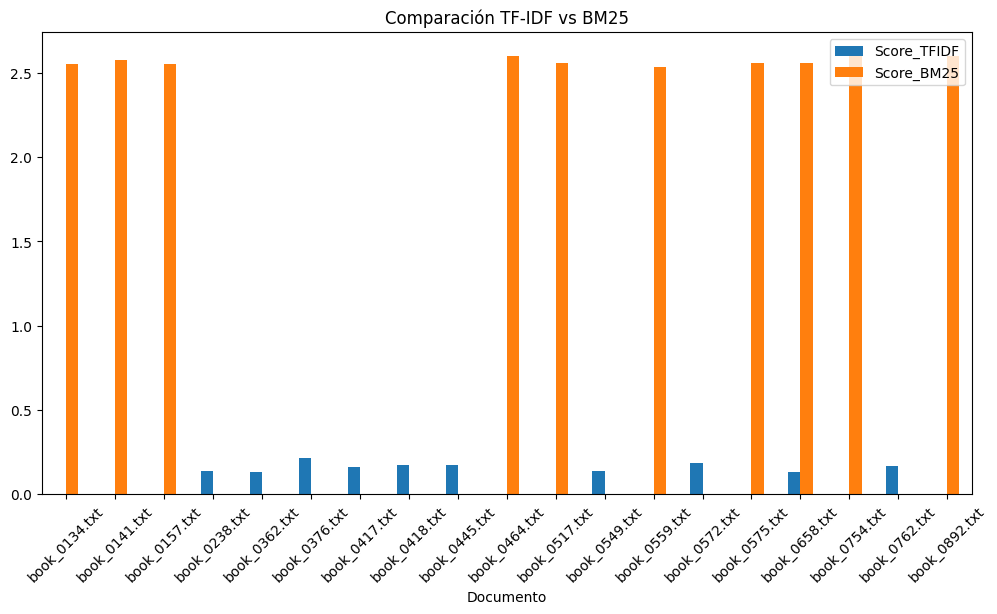

In [19]:
import matplotlib.pyplot as plt

comparacion.set_index("Documento")[["Score_TFIDF", "Score_BM25"]].plot(kind="bar", figsize=(12,6))

plt.title("Comparación TF-IDF vs BM25")
plt.xticks(rotation=45)
plt.show()

### Análisis del gráfico

Los valores de TF-IDF y BM25 no son directamente comparables en magnitud, ya que utilizan escalas diferentes.

En el gráfico se observa que BM25 asigna scores más altos a varios documentos que no aparecen en los primeros lugares del ranking TF-IDF. Esto indica que ambos modelos priorizan documentos diferentes.

BM25 considera la longitud del documento y aplica una normalización de la frecuencia de los términos, por lo que puede favorecer documentos donde los términos de la consulta aparecen de forma más equilibrada y representativa.

En cambio, TF-IDF se basa principalmente en la importancia de los términos dentro del corpus, sin aplicar la misma penalización por longitud del documento.

## Conclusión

Se logró comparar la recuperación de documentos usando TF-IDF y BM25. Los rankings obtenidos muestran que ambos modelos pueden recuperar documentos diferentes para una misma consulta, debido a la forma en que calculan la relevancia. BM25 ofrece una ventaja al considerar la longitud del documento y ajustar la frecuencia de los términos.